# KS 2 — The energy model, read out of the compiled C

Estimated time: 25–30 minutes

## Prerequisites
- **KS 1** (the hypothesis and why it needs a spatial model).
- A C toolchain, because this notebook calls the *actual* simulator code. The helper
  runs `make testlib` for you on first use.

## Learning aims
- **Primary scientific aim**: write down the three energy terms and say what each one
  physically resists or rewards.
- **Secondary modelling aim**: explain why the Monte Carlo scheme has two phases and a
  checkerboard, and what `h → |h|` and log-space acceptance are protecting against.

## Success criteria
- You can predict the shape of the total site energy for a cell containing 1 TCR and
  2 CD45, before plotting it.
- You can state why the bending term is evaluated as a *delta over five cells* rather
  than by summing over the grid.

## A note on method
Every curve below is produced by calling the compiled C through `ctypes` — the same
symbols `models/kinetic_segregation/tests/test_potentials.py` tests. Nothing here is a
numpy re-implementation. `src/ks_physics.h` is the single source of truth (KS rule 1),
so if the physics changes, these plots change with it instead of quietly disagreeing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ks_tutorial import COLOR_CD45, COLOR_TCR, DEFAULTS, ensure_potentials

lib = ensure_potentials()   # builds libks_potentials on first run

H0_TCR = DEFAULTS["h0_tcr"]          # 13 nm
U_ASSOC = DEFAULTS["u_assoc"]        # 20 kT
SIGMA_BIND = DEFAULTS["sigma_bind"]  # 3 nm
H_CD45 = DEFAULTS["cd45_height"]     # 50 nm
K_REP = 1.0                          # kT/nm^2, K_REP_BROWNIAN

E_tcr = np.vectorize(lambda h: lib.tcr_pmhc_potential(h, H0_TCR, U_ASSOC, SIGMA_BIND))
E_cd45 = np.vectorize(lambda h: lib.cd45_repulsion(h, H_CD45, K_REP))
print("loaded C potentials — E_tcr(13) =", round(float(E_tcr(13.0)), 3), "kT")

loaded C potentials — E_tcr(13) = -20.0 kT


## Term 1 — the TCR–pMHC well

$$E_{\mathrm{TCR}}(h) \;=\; -U_{\mathrm{assoc}}\,
\exp\!\left[-\frac{(h-h_0)^2}{2\sigma_{\mathrm{bind}}^2}\right]$$

A Gaussian well of depth $U_{\mathrm{assoc}} = 20\,k_BT$ and width
$\sigma_{\mathrm{bind}} = 3$ nm, **centred at $h_0 = 13$ nm** — the resting length of
the TCR–pMHC bridge.

That centring is worth pausing on. The well is *not* at $h=0$: the bond does not pull
the membranes into contact, it holds them at a specific, non-zero separation. A bound
TCR is equally unhappy if the membranes are too far apart *or* squeezed too close.

> **Documentation drift.** `Methods/methods.tex` currently writes this term as
> $\exp(-h^2/2\sigma^2)$, i.e. centred at $h=0$. The code centres it at `h0_tcr`. The
> code is what runs; the plot below is generated from it.

## Term 2 — the CD45 wall

$$E_{\mathrm{CD45}}(h) \;=\;
\begin{cases}
\tfrac{1}{2}\,k_{\mathrm{rep}}\,(h_{\mathrm{CD45}} - h)^2 & h < h_{\mathrm{CD45}}\\[2pt]
0 & h \ge h_{\mathrm{CD45}}
\end{cases}$$

A **one-sided** harmonic spring. Above 50 nm CD45 costs nothing at all; below it, the
penalty grows quadratically as the ectodomain is compressed. This is the term that
turns "CD45 is tall" into a force.

Note the asymmetry with term 1: the TCR term is attractive and *localised* (a well),
while the CD45 term is repulsive and *unbounded below* (a wall). Squeeze hard enough
and CD45 will always dominate.

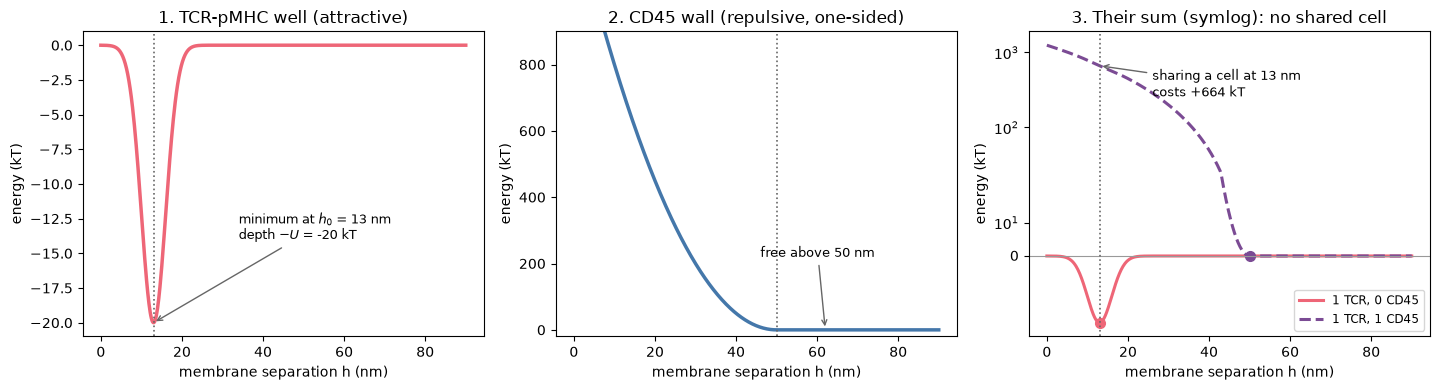

In [2]:
h = np.linspace(0, 90, 600)
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))

axes[0].plot(h, E_tcr(h), color=COLOR_TCR, lw=2.5)
axes[0].axvline(H0_TCR, color="#666", ls=":", lw=1.2)
axes[0].annotate(f"minimum at $h_0$ = {H0_TCR:.0f} nm\ndepth $-U$ = {-U_ASSOC:.0f} kT",
                 xy=(H0_TCR, -U_ASSOC), xytext=(34, -14), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="#666"))
axes[0].set_title("1. TCR-pMHC well (attractive)")

axes[1].plot(h, E_cd45(h), color=COLOR_CD45, lw=2.5)
axes[1].axvline(H_CD45, color="#666", ls=":", lw=1.2)
axes[1].annotate(f"free above {H_CD45:.0f} nm", xy=(62, 2), xytext=(46, 220),
                 fontsize=9, arrowprops=dict(arrowstyle="->", color="#666"))
axes[1].set_ylim(-20, 900)
axes[1].set_title("2. CD45 wall (repulsive, one-sided)")

# Total site energy: one TCR alone, versus one TCR sharing its cell with CD45.
for n_tcr, n_cd45, style, col in [(1, 0, "-", COLOR_TCR), (1, 1, "--", "#7B4B94")]:
    total = n_tcr * E_tcr(h) + n_cd45 * E_cd45(h)
    axes[2].plot(h, total, style, lw=2.2, color=col, label=f"{n_tcr} TCR, {n_cd45} CD45")
    axes[2].plot(h[np.argmin(total)], total.min(), "o", ms=7, color=col)

cost_together = float(E_tcr(H0_TCR) + E_cd45(H0_TCR))
axes[2].set_yscale("symlog", linthresh=25)
axes[2].axhline(0, color="#999", lw=0.8)
axes[2].axvline(H0_TCR, color="#666", ls=":", lw=1.2)
axes[2].annotate(f"sharing a cell at 13 nm\ncosts {cost_together:+.0f} kT",
                 xy=(H0_TCR, cost_together), xytext=(26, 260), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="#666"))
axes[2].legend(fontsize=8.5, loc="lower right")
axes[2].set_title("3. Their sum (symlog): no shared cell")

for a in axes:
    a.set_xlabel("membrane separation h (nm)"); a.set_ylabel("energy (kT)")
plt.tight_layout(); plt.show()

### Reading panel 3 — the exclusion is not subtle

Note the **symlog** y-axis: a linear one cannot show both curves at once, and that is
the point.

- **1 TCR alone** (solid): minimum in the well at 13 nm. Contact forms.
- **1 TCR sharing its cell with one CD45** (dashed): at 13 nm the CD45 wall contributes
  $\tfrac{1}{2}k_{\rm rep}(50-13)^2 \approx 685\,k_BT$. The 20 kT of binding energy is
  not remotely enough to pay for it. The minimum jumps out to $h \ge 50$ nm, where CD45
  is finally free.

So this is not a soft bias that shifts a well by a few kT. With the default
$k_{\rm rep} = 1\,k_BT/\mathrm{nm}^2$, **a single CD45 makes tight contact
energetically impossible in that cell** — by a factor of ~34 over the entire binding
energy.

Which raises the question the simulation exists to answer. If a cell cannot host both,
then the system must *sort itself in space*: TCR-rich regions become CD45-free and
vice versa. Where does the boundary between them fall? How sharp is it? How does it
move when you stiffen the membrane? Those are collective, many-body questions, and no
single-site energy curve can answer them — only sampling can.

## Term 3 — membrane bending

$$E_{\mathrm{bend}} \;=\; \frac{\kappa}{2}\sum_{ij}\left(\nabla^2_d h_{ij}\right)^2 \Delta x^2$$

the discrete Helfrich energy, with a five-point Laplacian and **periodic** boundaries.

The simulator never evaluates that sum. Moving one grid cell changes the Laplacian at
exactly five sites — the cell itself and its four neighbours — so `bending_energy_delta`
computes the change in **O(1)** instead of O(N²). With a 64×64 grid updated tens of
thousands of times, that difference is the whole feasibility of the model.

Below we verify the physics the shortcut is supposed to preserve: on a flat membrane,
displacing one cell by $\delta$ should cost energy $\propto \kappa\,\delta^2$.

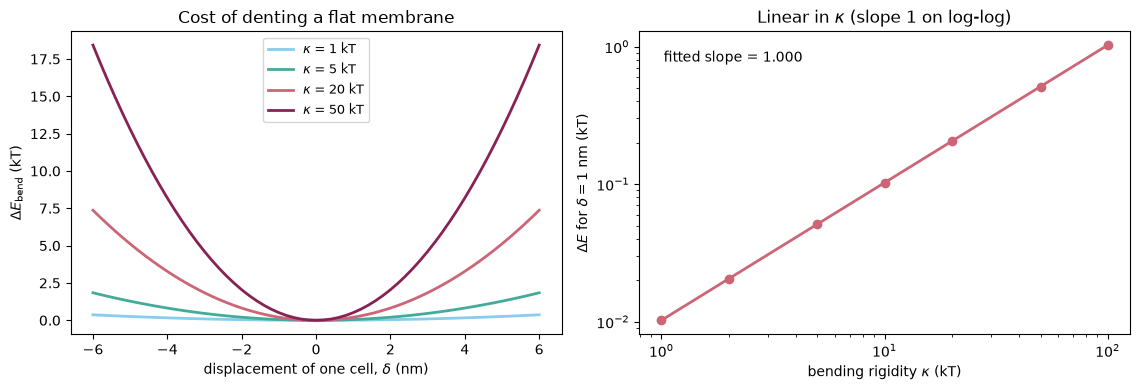

scaling with kappa : exponent 1.0000  (expected 1)
scaling with delta : exponent 2.0000  (expected 2)


In [3]:
import ctypes

N, DX = 32, 2000.0 / 64.0     # grid cells, nm per cell


def bend_cost(kappa, delta, base=None):
    """Energy cost of displacing the centre cell by `delta` nm.

    API contract worth knowing: `bending_energy_delta` expects the height array
    to ALREADY contain the new value. It recovers the old Laplacians by
    subtracting the known shift -- that is what makes it O(1). Hand it the
    un-updated field and you get a meaningless (negative) answer.
    """
    field = np.full((N, N), DEFAULTS["init_height"]) if base is None else base.copy()
    gi = gj = N // 2
    old = float(field[gi, gj])
    new = old + delta
    field[gi, gj] = new                        # <- update BEFORE calling
    buf = (ctypes.c_double * field.size)(*field.ravel())
    return lib.bending_energy_delta(buf, N, kappa, DX, gi, gj, old, new)


deltas = np.linspace(-6, 6, 61)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4))

for kappa, color in [(1.0, "#88CCEE"), (5.0, "#44AA99"), (20.0, "#CC6677"), (50.0, "#882255")]:
    axL.plot(deltas, [bend_cost(kappa, d) for d in deltas],
             color=color, lw=2, label=f"$\\kappa$ = {kappa:g} kT")

axL.set_xlabel("displacement of one cell, $\\delta$ (nm)")
axL.set_ylabel(r"$\Delta E_{\rm bend}$ (kT)")
axL.set_title("Cost of denting a flat membrane"); axL.legend(fontsize=9)

# Is it really quadratic in delta and linear in kappa?
kappas = np.array([1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0])
cost = np.array([bend_cost(k, 1.0) for k in kappas])
axR.plot(kappas, cost, "o-", color="#CC6677", lw=2)
axR.set_xscale("log"); axR.set_yscale("log")
axR.set_xlabel(r"bending rigidity $\kappa$ (kT)")
axR.set_ylabel(r"$\Delta E$ for $\delta = 1$ nm (kT)")
axR.set_title("Linear in $\\kappa$ (slope 1 on log-log)")

slope = np.polyfit(np.log(kappas), np.log(cost), 1)[0]
pos = deltas[deltas > 0.5]
quad = np.polyfit(np.log(pos), np.log([bend_cost(20.0, d) for d in pos]), 1)[0]
axR.text(0.05, 0.9, f"fitted slope = {slope:.3f}", transform=axR.transAxes, fontsize=10)
plt.tight_layout(); plt.show()

print(f"scaling with kappa : exponent {slope:.4f}  (expected 1)")
print(f"scaling with delta : exponent {quad:.4f}  (expected 2)")

### Why this matters for the biology

Bending is the term that makes rigidity a **control parameter**. Every TCR bond that
pulls the membrane down to 13 nm must pay $\propto\kappa$ to do it. Stiffen the
membrane and the same bond buys you less deformation — so less CD45 exclusion, so less
signal.

That is the first prediction you held in KS 1, and you will measure it in KS 4.

## The Monte Carlo scheme

One `sim_step` is one **sweep**: every degree of freedom gets proposed exactly once.

**Phase 1 — molecules.** For each TCR, then each CD45: propose a Gaussian lateral
displacement, wrap periodically, look up the membrane height at the new cell, and
accept or reject on the energy change.

**Phase 2 — membrane heights, on a red/black checkerboard.** Grid cells are coloured
like a chessboard and updated one colour at a time.

The checkerboard is not an optimisation detail; it is a correctness requirement. The
five-point Laplacian couples each cell to its four nearest neighbours, and those
neighbours are always the *opposite* colour. So when all red cells are updated
simultaneously, every energy they depend on belongs to a black cell that is not
changing — the parallel update is exactly equivalent to a sequential one. Update
neighbouring cells at the same time and you would be computing each cell's energy
against a membrane that has already moved underneath it.

### Two implementation details worth understanding

**Log-space acceptance.** The Metropolis criterion is applied as

```
accept if  ΔE <= 0  or  log(u) < -ΔE        with u ~ U(0,1)
```

rather than the textbook `u < exp(-ΔE)`. Algebraically identical, numerically not: for
a strongly rejected move, `exp(-ΔE)` underflows to zero and you lose the ability to
distinguish "very unlikely" from "impossible". Comparing logarithms never underflows,
so no capping of ΔE is needed anywhere in the code.

**Reflection, not clamping.** A proposed height below zero is *reflected*,
$h \to |h|$, rather than clamped to zero. Clamping would pile probability mass onto
exactly $h=0$ — an artificial absorbing state at the wall, and one that breaks
detailed balance. Reflection maps the forbidden region back into the allowed one
symmetrically, so the sampled distribution stays correct.

## Scientific checkpoint

1. The TCR well is 20 kT deep, and thermal energy is 1 kT. Why does the model still
   need Monte Carlo rather than just placing every TCR at its energy minimum?
2. Why is the CD45 term one-sided instead of a symmetric harmonic well?
3. On a *curved* membrane rather than a flat one, would displacing a cell by $\delta$
   still cost $\propto\delta^2$?

<details>
<summary>Check yourself</summary>

1. Because the well is deep in *height*, not in *lateral position*. A TCR pays almost
   nothing to diffuse sideways, and CD45's exclusion is an entropic, many-body,
   collective effect — the observable is a distribution over configurations, not a
   ground state. A minimiser would also give you no notion of a fluctuating membrane.
2. Because CD45 is a physical strut, not a bond. It resists being compressed and is
   indifferent to being further away — there is nothing pulling it toward the opposing
   membrane. A symmetric well would wrongly make CD45 *prefer* a 50 nm gap.
3. No — only the leading term. The delta contains a cross-term between $\delta$ and
   the existing local curvature, so on a curved patch the cost is
   $a\delta + b\delta^2$ with $a \neq 0$. It is exactly quadratic here only because we
   started from a flat membrane, where the linear term vanishes by symmetry. Try
   re-running the left panel from a non-flat `flat` array to see it.
</details>

## Where to go next

**KS 3 — your first simulation**: run the model, and read every key it returns.

In [4]:
# Final check: the physics this notebook claims, verified against the C.
assert abs(E_tcr(H0_TCR) - (-U_ASSOC)) < 1e-9, "TCR well minimum is not at h0_tcr"
assert abs(float(E_tcr(H0_TCR + 30))) < 1e-6, "well should vanish far from h0"
assert E_cd45(H_CD45 + 5) == 0.0, "CD45 term must be exactly zero above its height"
assert E_cd45(H_CD45 - 10) > 0, "CD45 term must penalise compression"
assert abs(slope - 1.0) < 0.01, f"bending should be linear in kappa, got {slope}"
assert abs(quad - 2.0) < 0.05, f"bending should be quadratic in delta, got {quad}"
print("[KS_2 self-check OK]")

[KS_2 self-check OK]
